In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42

# EDA

In [35]:
train = pd.read_csv("../churn-predictor/data/train.csv")
test = pd.read_csv("../churn-predictor/data/test.csv")

train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [36]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [37]:
train.describe()

,id,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,594194.000000,594194.000000,594194.000000,594194.000000,594194.000000
mean,297096.500000,0.114102,36.577258,65.866223,2494.377057
std,171529.177262,0.317936,25.061922,31.067444,2353.916710
min,0.000000,0.000000,1.000000,18.250000,18.800000
25%,148548.250000,0.000000,12.000000,29.900000,639.650000
50%,297096.500000,0.000000,35.000000,74.100000,1433.650000
75%,445644.750000,0.000000,62.000000,90.800000,4263.800000
max,594193.000000,1.000000,72.000000,118.750000,8684.800000


<Axes: xlabel='Churn'>

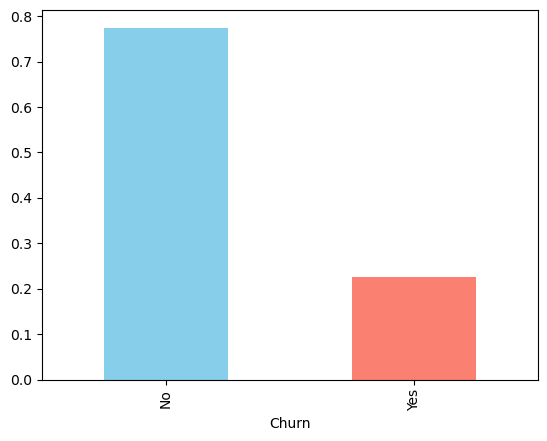

In [38]:
train['Churn'].value_counts(normalize=True).plot(kind='bar', color=['skyblue', 'salmon'], )

In [39]:
# Encode Churn for numerical analysis
train["Churn"] = train["Churn"].map({"Yes": 1, "No": 0})

NUMERICAL = ["tenure", "MonthlyCharges", "TotalCharges"]
CATEGORICAL = [
    "gender", "SeniorCitizen", "Partner", "Dependents", "PhoneService",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaperlessBilling", "PaymentMethod"
]

## Univariate Analysis

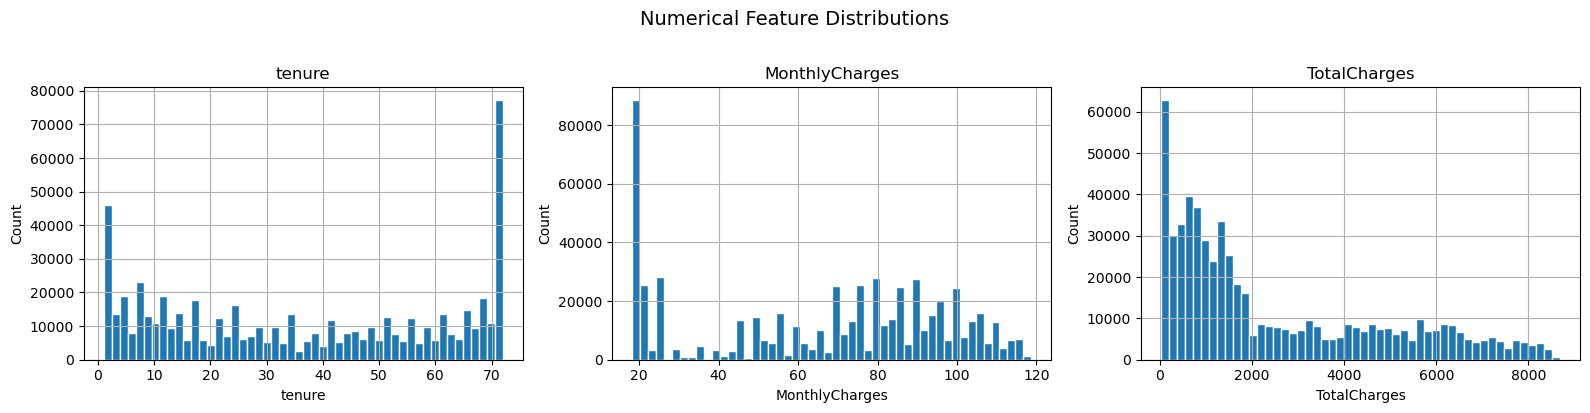

In [40]:
# Numerical distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, NUMERICAL):
    train[col].hist(bins=50, ax=ax, edgecolor="white")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
plt.suptitle("Numerical Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

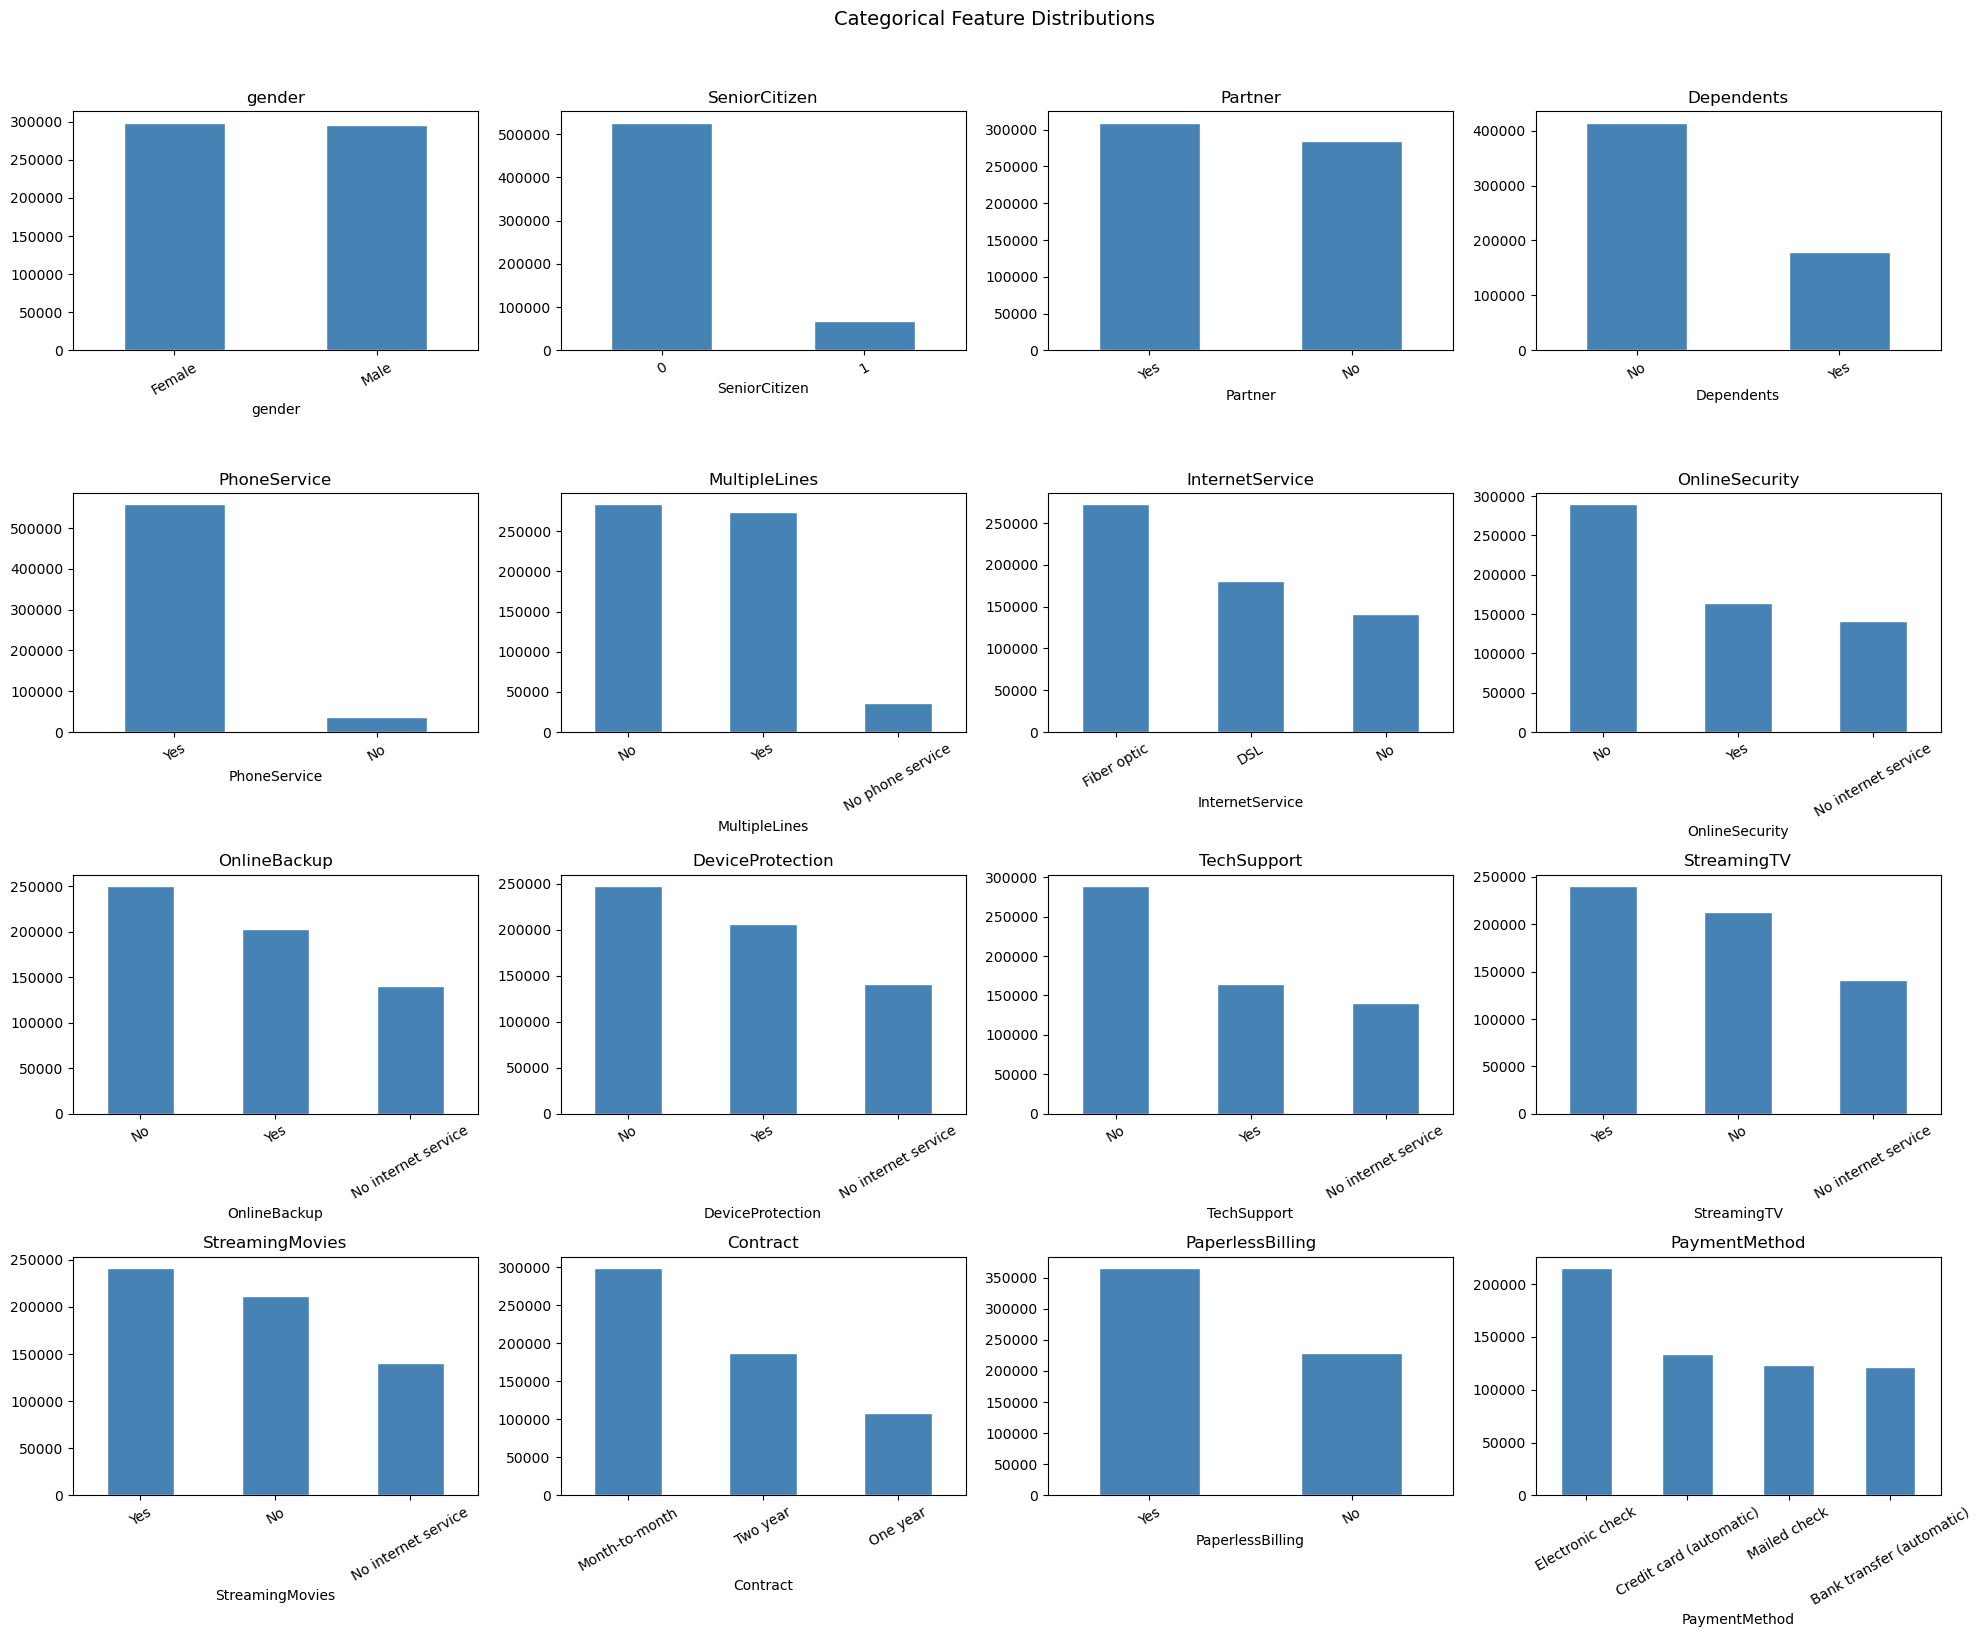

In [41]:
# Categorical distributions
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for ax, col in zip(axes, CATEGORICAL):
    train[col].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
for ax in axes[len(CATEGORICAL):]:
    ax.set_visible(False)
plt.suptitle("Categorical Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Bivariate Analysis

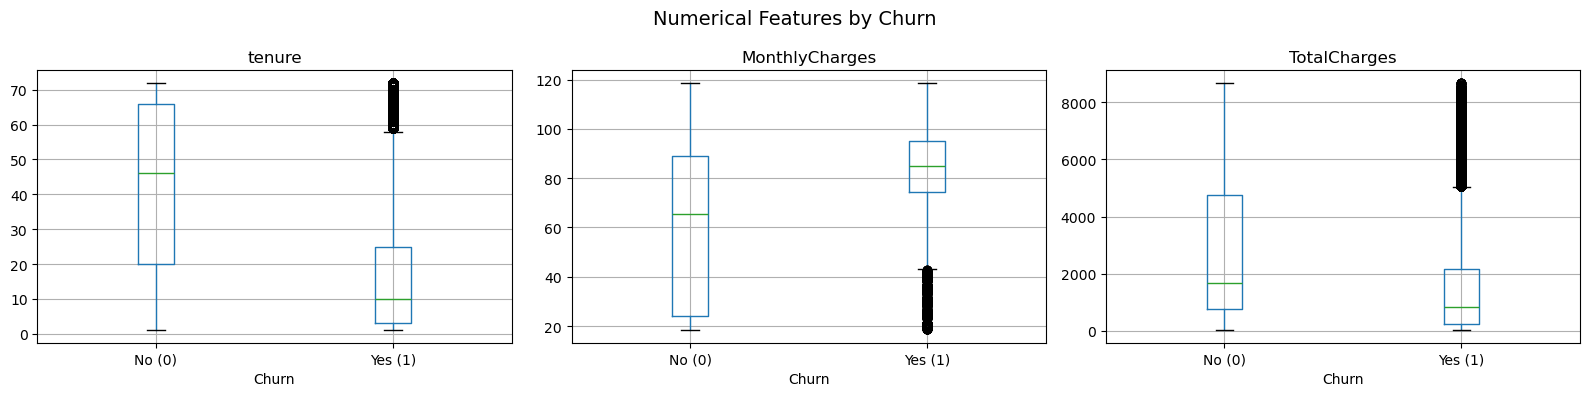

In [42]:
# Numerical features vs Churn — boxplots
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, NUMERICAL):
    train.boxplot(column=col, by="Churn", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("Churn")
    ax.set_xticklabels(["No (0)", "Yes (1)"])
plt.suptitle("Numerical Features by Churn", fontsize=14)
plt.tight_layout()
plt.show()

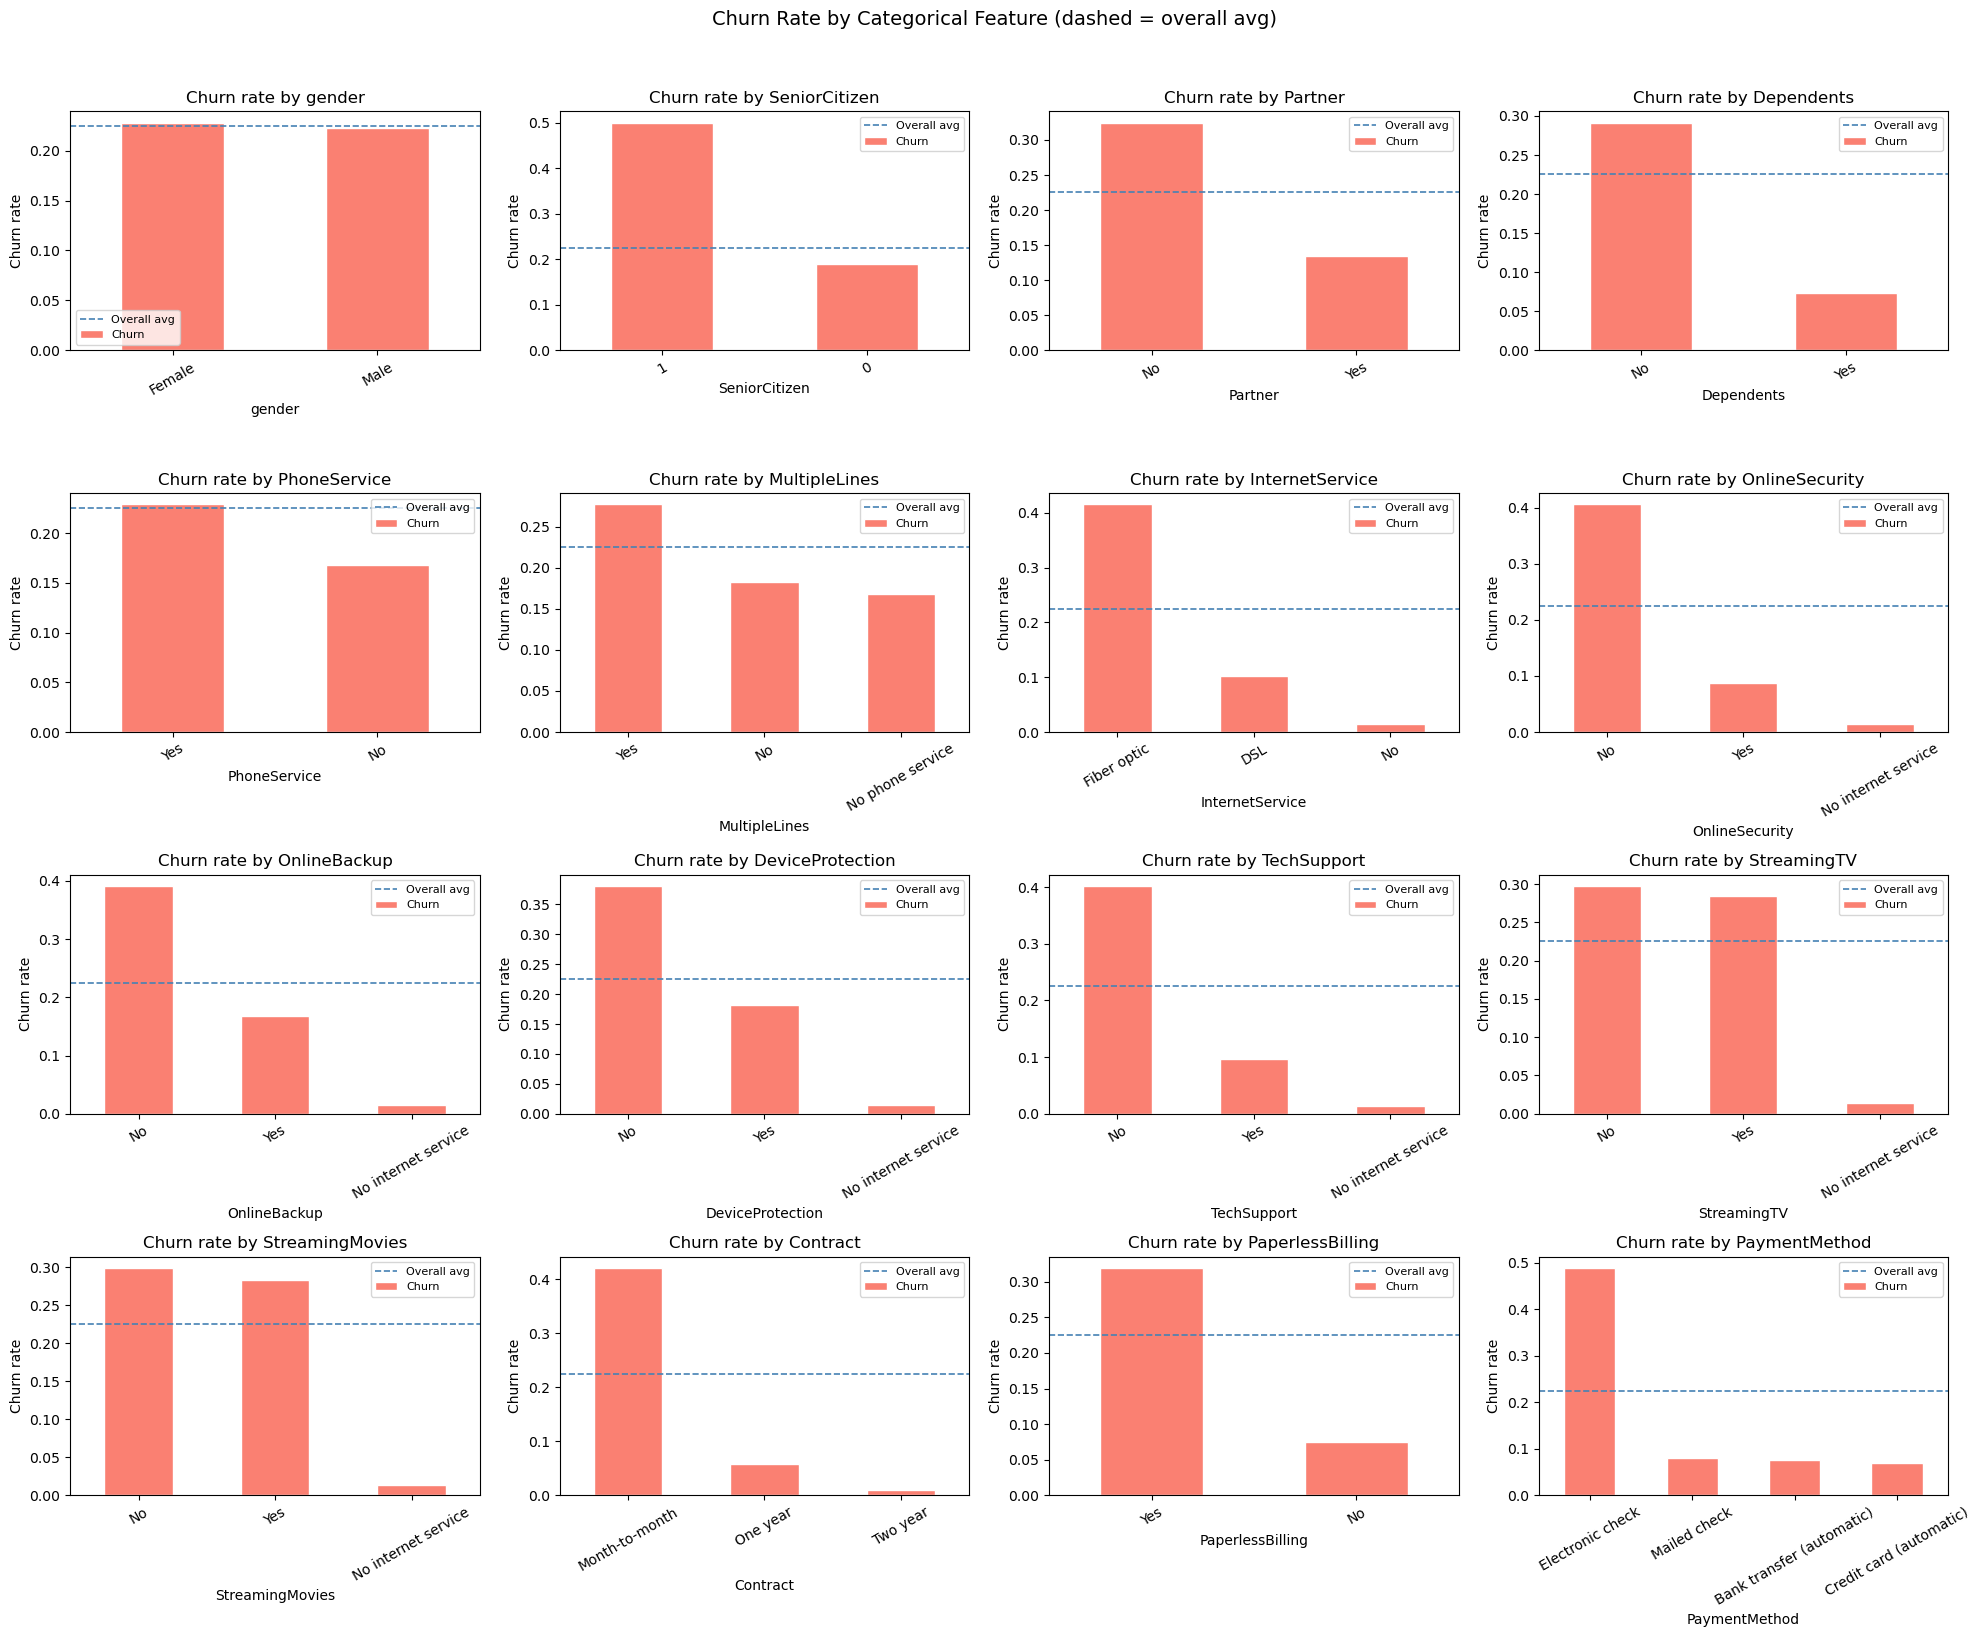

In [43]:
# Categorical features vs Churn — churn rate per category
baseline = train["Churn"].mean()

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()
for ax, col in zip(axes, CATEGORICAL):
    churn_rate = train.groupby(col)["Churn"].mean().sort_values(ascending=False)
    churn_rate.plot(kind="bar", ax=ax, color="salmon", edgecolor="white")
    ax.axhline(baseline, color="steelblue", linestyle="--", linewidth=1.2, label="Overall avg")
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(fontsize=8)
for ax in axes[len(CATEGORICAL):]:
    ax.set_visible(False)
plt.suptitle("Churn Rate by Categorical Feature (dashed = overall avg)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

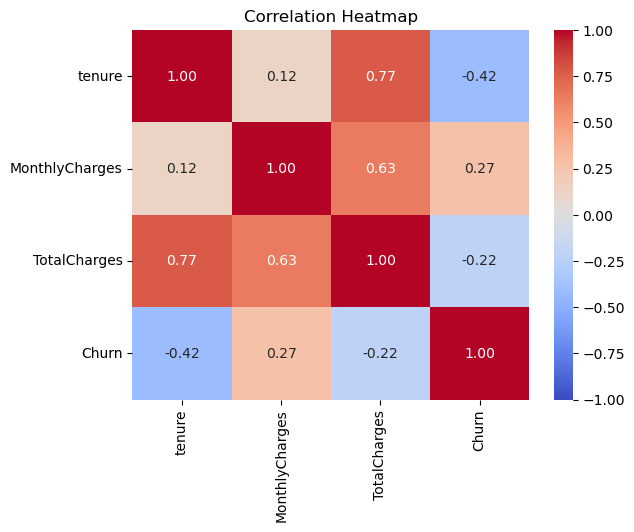

In [44]:
# Correlation heatmap
corr_cols = NUMERICAL + ["Churn"]
sns.heatmap(train[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

# Feature Engineering

In [45]:
from sklearn.model_selection import train_test_split

ADDON_COLS = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

def engineer_features(df):
    df = df.copy()

    # Recode "No internet service" → 0 for addon cols, then map Yes/No → 1/0
    for col in ADDON_COLS:
        df[col] = df[col].replace("No internet service", "No").map({"Yes": 1, "No": 0})

    # num_addons: count of opted-in addon services
    df["num_addons"] = df[ADDON_COLS].sum(axis=1)

    # tenure_bucket: new / mid / long customer
    df["tenure_bucket"] = pd.cut(
        df["tenure"],
        bins=[0, 12, 36, 72],
        labels=["new", "mid", "long"]
    )

    # has_family: has partner or dependents
    df["has_family"] = ((df["Partner"] == "Yes") | (df["Dependents"] == "Yes")).astype(int)

    # is_auto_payment: bank transfer or credit card automatic
    df["is_auto_payment"] = df["PaymentMethod"].isin(
        ["Bank transfer (automatic)", "Credit card (automatic)"]
    ).astype(int)

    return df

train = engineer_features(train)
test = engineer_features(test)

# Split train into train/val — stratified to preserve churn ratio
X = train.drop(columns=["Churn", "id"])
y = train["Churn"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Churn rate — train: {y_train.mean():.3f}, val: {y_val.mean():.3f}")

X_train: (475355, 23), X_val: (118839, 23)
Churn rate — train: 0.225, val: 0.225


# Modelling

In [46]:
# Cast categoricals to category dtype — LightGBM handles these natively
CAT_COLS = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService",
    "Contract", "PaperlessBilling", "PaymentMethod", "tenure_bucket"
]

for col in CAT_COLS:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")

In [47]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, confusion_matrix

In [48]:
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "verbose": -1,
    "seed": SEED,
}

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_val],
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
)


Training until validation scores don't improve for 50 rounds
[100]	valid_0's auc: 0.914124
[200]	valid_0's auc: 0.915554
[300]	valid_0's auc: 0.915952
[400]	valid_0's auc: 0.916127
[500]	valid_0's auc: 0.916215
[600]	valid_0's auc: 0.916282
[700]	valid_0's auc: 0.916355
[800]	valid_0's auc: 0.916392
Early stopping, best iteration is:
[839]	valid_0's auc: 0.916412


Validation AUC: 0.9164


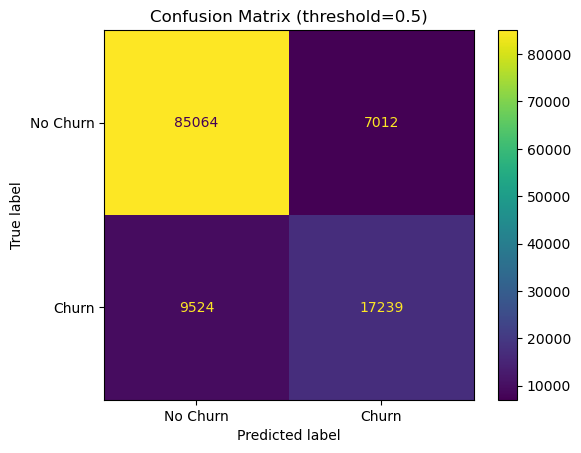

In [49]:
val_preds = model.predict(X_val)
auc = roc_auc_score(y_val, val_preds)
print(f"Validation AUC: {auc:.4f}")

# Confusion matrix at 0.5 threshold
cm = confusion_matrix(y_val, (val_preds >= 0.5).astype(int))
ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot()
plt.title("Confusion Matrix (threshold=0.5)")
plt.show()


# Hyperparams Tuning

In [50]:
import optuna

In [51]:
def objective(trial):
    params = {
        "objective": "binary",
        "metric": "auc",
        "verbose": -1,
        "seed": SEED,
        "feature_pre_filter": False,
        "learning_rate": 0.05,  # fix this, tune with num_boost_round instead
        "num_leaves": trial.suggest_int("num_leaves", 20, 80),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 100),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
    }

    lgb_train = lgb.Dataset(X_train, label=y_train)
    lgb_val = lgb.Dataset(X_val, label=y_val, reference=lgb_train)

    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=500,       # lower ceiling
        valid_sets=[lgb_val],
        callbacks=[lgb.early_stopping(10), lgb.log_evaluation(-1)],
    )

    trial.set_user_attr("best_iteration", model.best_iteration)
    return model.best_score["valid_0"]["auc"]

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Best AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


[I 2026-03-21 01:00:27,418] A new study created in memory with name: no-name-6b4d45b2-6d1a-4de4-80b2-2d55bce1fe50


  0%|          | 0/30 [00:00<?, ?it/s]

Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[431]	valid_0's auc: 0.916286
[I 2026-03-21 01:00:35,507] Trial 0 finished with value: 0.916286169714448 and parameters: {'num_leaves': 42, 'min_child_samples': 97, 'feature_fraction': 0.8927975767245621}. Best is trial 0 with value: 0.916286169714448.
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[347]	valid_0's auc: 0.916371
[I 2026-03-21 01:00:43,431] Trial 1 finished with value: 0.9163712948858084 and parameters: {'num_leaves': 56, 'min_child_samples': 32, 'feature_fraction': 0.662397808134481}. Best is trial 1 with value: 0.9163712948858084.
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[499]	valid_0's auc: 0.916286
[I 2026-03-21 01:00:50,397] Trial 2 finished with value: 0.9162855563382585 and parameters: {'num_leaves': 23, 'min_child_samples': 90, 'feature_fraction': 0.8404

In [52]:
study.best_params

{'num_leaves': 51,
 'min_child_samples': 67,
 'feature_fraction': 0.6185801650879991}

# Retrain with full data

In [53]:
best_params = {
    "objective": "binary",
    "metric": "auc",
    "verbose": -1,
    "seed": SEED,
    "learning_rate": 0.05,
    **study.best_params,
}

X_full = pd.concat([X_train, X_val])
y_full = pd.concat([y_train, y_val])

lgb_full = lgb.Dataset(X_full, label=y_full)

final_model = lgb.train(
    best_params,
    lgb_full,
    num_boost_round=study.best_trial.user_attrs["best_iteration"],  # best iteration from best Optuna trial
)


In [54]:
import joblib, json, os
os.makedirs("../models", exist_ok=True)

joblib.dump(final_model, "../models/lgb_model_v1.joblib")

with open("../models/best_params_lgb_v1.json", "w") as f:
    json.dump(study.best_params, f, indent=2)

print("Final model saved.")

Final model saved.


# Predict on test data

In [56]:
# Predict on test data
X_test = test.drop(columns=["id"])

# Cast categoricals to match training
for col in CAT_COLS:
    X_test[col] = X_test[col].astype("category")

test_preds = final_model.predict(X_test)

# Convert probabilities to binary labels
submission = pd.DataFrame({
    "id": test["id"],
    "Churn": (test_preds >= 0.5).astype(int)
})

submission.to_csv("../submission.csv", index=False)
print(submission.head())
print(f"Churn rate in submission: {submission['Churn'].mean():.3f}")


       id  Churn
0  594194      0
1  594195      0
2  594196      0
3  594197      0
4  594198      1
Churn rate in submission: 0.195
